## Realizo ajustes en loop con cfgbounds

Acá voy a implementar mis funciones de fitting.py que están hechas para:
- Picos EMG en las señales NMC 
- Parámetro $\lambda$ fijo (se ajusta en el primer ciclo del loop y luego se mantiene constante)
- Dict cfg_bounds donde elijo restricciones para cada pico en particular

In [1]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [2]:
import numpy as np
import pandas as pd

In [3]:
import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft

In [4]:
# --- carga de datos ---
path_json = "../tmp/NMC-20.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())

Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 301


In [5]:
# --- Selección de ciclos ---
ciclos_sel = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    rango=(21, 900),
    excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 288 ciclos seleccionados
   → [21, 24, 27, 33, 36, 39, 42, 45, 48, 51]...


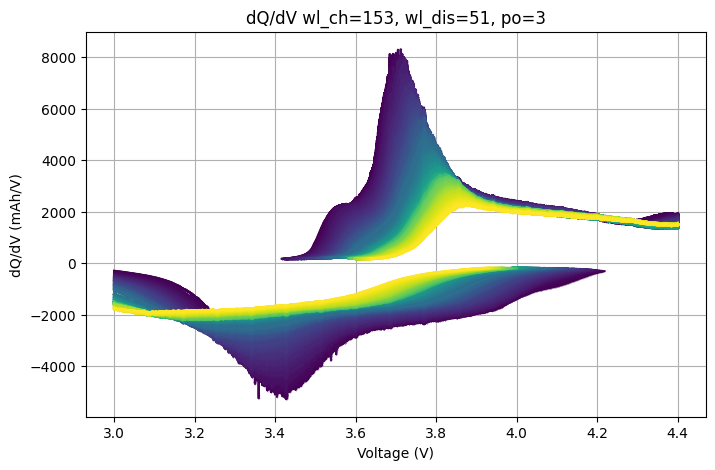

"\ndiccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},\n        99: {'Ch': df_ch_99, 'Dis': df_dis_99},\n        ...: {...}}\n"

In [6]:
# --- Trunco datos y calculo derivada ---

# Para NMC-20:
# charge (wl = 153, truncar los n=30 puntos iniciales)
# discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)
# Esto se debe a que la señal de carga tiene 3 veces mas resolución que la de descarga.
# Estos valores pueden cambiar según el dataset.

diccio = dr.truncar_señal(ciclos_sel, dict_ciclos_sep, n_dis=10, n_ch=30)
diccio =  dr.plot_dqdV(ciclos_sel, diccio)

'''
diccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},
        99: {'Ch': df_ch_99, 'Dis': df_dis_99},
        ...: {...}}
'''
# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

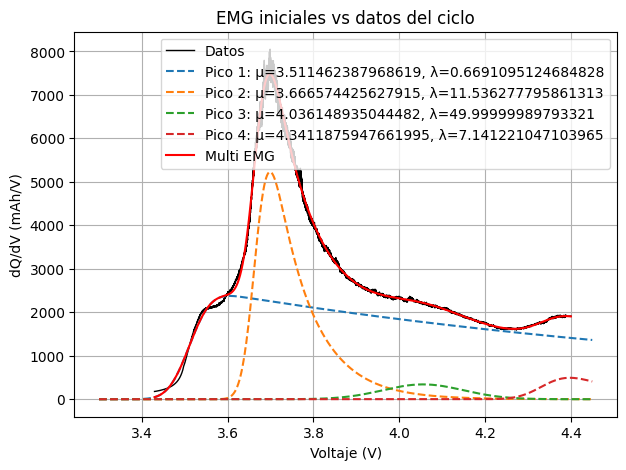

In [7]:
# --- Pruebo manualmente guess inicial para parametros de ajuste ---

# En la EMG los parámetros son: (amplitud, media, sigma, lambda)

df_ch = diccio[21]['Ch']
param_guess = [(5400, 3.51, 0.04, 0.4), 
               (1000, 3.67, 0.03, 9), 
               (200, 4.0, 0.1, 5), 
               (220, 4.34, 0.09, 6)]

param_guess = [(3814.876992578531,3.511462387968619,0.03937649023787247,0.6691095124684828),
               (747.9674505882472,3.666574425627915,0.024883050612290222,11.536277795861313),
               (80.48153481362431,4.036148935044482,0.09212835375737331,49.99999989793321),
               (120.28718521872311,4.3411875947661995,0.04625798093742598,7.141221047103965)]


ft.plot_emg_guess(df_ch, param_guess)

### Ajuste de ciclo 21 a 900

In [8]:
param_guess = [(5400, 3.51, 0.02, 0.4), 
               (1000, 3.67, 0.03, 9), 
               (200, 4.0, 0.1, 5), 
               (220, 4.34, 0.09, 6)]

param_guess = [(3814.876992578531,3.511462387968619,0.03937649023787247,0.6691095124684828),
               (747.9674505882472,3.666574425627915,0.024883050612290222,11.536277795861313),
               (80.48153481362431,4.036148935044482,0.09212835375737331,49.99999989793321),
               (120.28718521872311,4.3411875947661995,0.04625798093742598,7.141221047103965)]

cfg_bounds_default = {
    'perc_a': 0.1,
    'perc_mu': 0.1,
    'perc_sigma': 0.1,
    'restricciones_mu': {2: (3.5, 4.45), 3: (3.5, 4.45)}
}

cfg_bounds_especifico3y4 = {
    'perc_a': 0.1,
    'perc_mu': 0.1,
    'perc_sigma': 0.1,
    'restricciones_mu': {2: (3.9, 4.3), 3: (4.3, 4.45)},
    'restricciones_sigma': {3: (0.02, 0.09)}
}

cfg_bounds_relajado = {
    'perc_a': 0.2,
    'perc_mu': 0.15,
    'perc_sigma': 0.2
}

Ajustando ciclo 21...


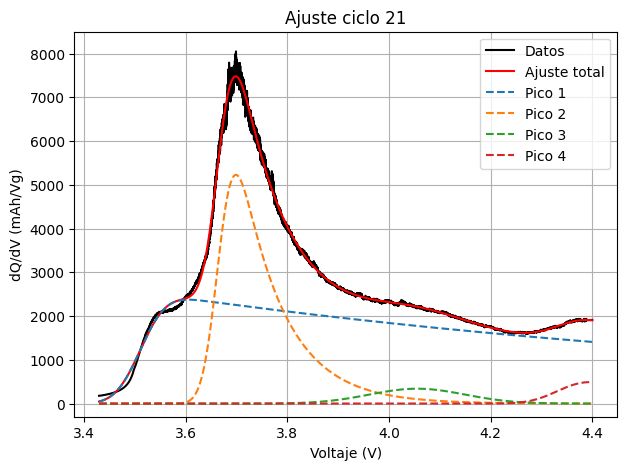

Ajustando ciclo 24...
Ajustando ciclo 27...
Ajustando ciclo 33...
Ajustando ciclo 36...
Ajustando ciclo 39...
Ajustando ciclo 42...
Ajustando ciclo 45...
Ajustando ciclo 48...
Ajustando ciclo 51...
Ajustando ciclo 54...
Ajustando ciclo 57...
Ajustando ciclo 60...
Ajustando ciclo 63...


/home/mariajose/proc-icdv/src/fitting.py:32: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:31: RuntimeWarning: invalid value encountered in multiply
  return (a * (lambd/2) *


Ajustando ciclo 66...
Ajustando ciclo 69...


/home/mariajose/proc-icdv/src/fitting.py:307: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(f, V, dqdv, p0=p0, bounds=bounds, maxfev=maxfev)


Ajustando ciclo 72...
Ajustando ciclo 75...
Ajustando ciclo 78...
Ajustando ciclo 81...
Ajustando ciclo 84...
Ajustando ciclo 87...
Ajustando ciclo 90...
Ajustando ciclo 93...
Ajustando ciclo 96...
Ajustando ciclo 99...


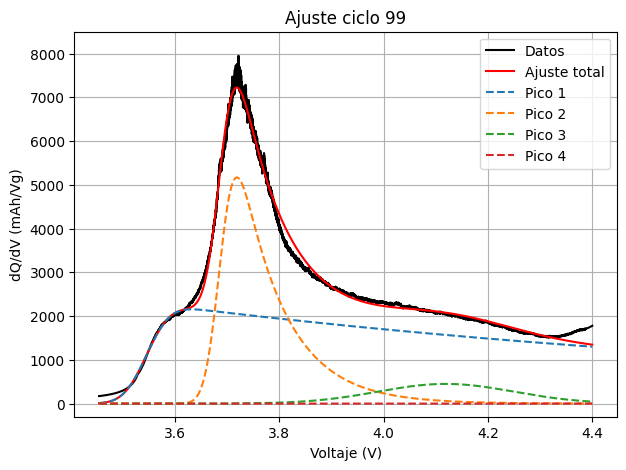

Ajustando ciclo 102...
Ajustando ciclo 105...
Ajustando ciclo 108...
Ajustando ciclo 111...
Ajustando ciclo 114...
Ajustando ciclo 117...
Ajustando ciclo 120...
Ajustando ciclo 123...
Ajustando ciclo 126...
Ajustando ciclo 129...
Ajustando ciclo 132...
Ajustando ciclo 135...
Ajustando ciclo 138...
Ajustando ciclo 141...
Ajustando ciclo 144...
Ajustando ciclo 147...
Ajustando ciclo 150...
Ajustando ciclo 153...
Ajustando ciclo 156...
Ajustando ciclo 159...
Ajustando ciclo 162...
Ajustando ciclo 165...
Ajustando ciclo 168...
Ajustando ciclo 171...
Ajustando ciclo 174...
Ajustando ciclo 177...
Ajustando ciclo 180...
Ajustando ciclo 183...
Ajustando ciclo 195...
Ajustando ciclo 198...


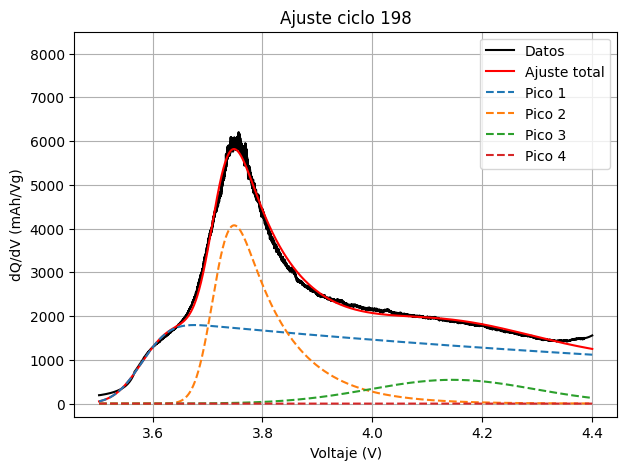

Ajustando ciclo 201...
Ajustando ciclo 204...
Ajustando ciclo 207...
Ajustando ciclo 210...
Ajustando ciclo 213...
Ajustando ciclo 216...
Ajustando ciclo 219...
Ajustando ciclo 222...
Ajustando ciclo 225...
Ajustando ciclo 228...
Ajustando ciclo 231...
Ajustando ciclo 234...
Ajustando ciclo 237...
Ajustando ciclo 240...
Ajustando ciclo 243...
Ajustando ciclo 246...
Ajustando ciclo 249...
Ajustando ciclo 252...
Ajustando ciclo 255...
Ajustando ciclo 258...
Ajustando ciclo 261...
Ajustando ciclo 264...
Ajustando ciclo 267...
Ajustando ciclo 270...
Ajustando ciclo 273...
Ajustando ciclo 276...
Ajustando ciclo 279...
Ajustando ciclo 282...
Ajustando ciclo 285...
Ajustando ciclo 288...
Ajustando ciclo 291...
Ajustando ciclo 294...
Ajustando ciclo 297...


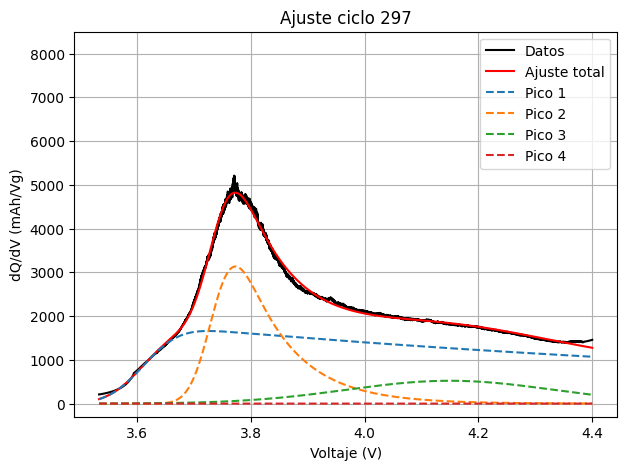

Ajustando ciclo 300...
Ajustando ciclo 303...
Ajustando ciclo 306...
Ajustando ciclo 309...
Ajustando ciclo 312...
Ajustando ciclo 315...
Ajustando ciclo 318...
Ajustando ciclo 321...
Ajustando ciclo 324...
Ajustando ciclo 327...
Ajustando ciclo 330...
Ajustando ciclo 333...
Ajustando ciclo 336...
Ajustando ciclo 339...
Ajustando ciclo 342...
Ajustando ciclo 345...
Ajustando ciclo 348...
Ajustando ciclo 351...
Ajustando ciclo 354...
Ajustando ciclo 357...
Ajustando ciclo 360...
Ajustando ciclo 363...
Ajustando ciclo 366...
Ajustando ciclo 369...
Ajustando ciclo 372...
Ajustando ciclo 375...
Ajustando ciclo 378...
Ajustando ciclo 381...
Ajustando ciclo 384...
Ajustando ciclo 387...
Ajustando ciclo 390...
Ajustando ciclo 393...
Ajustando ciclo 396...


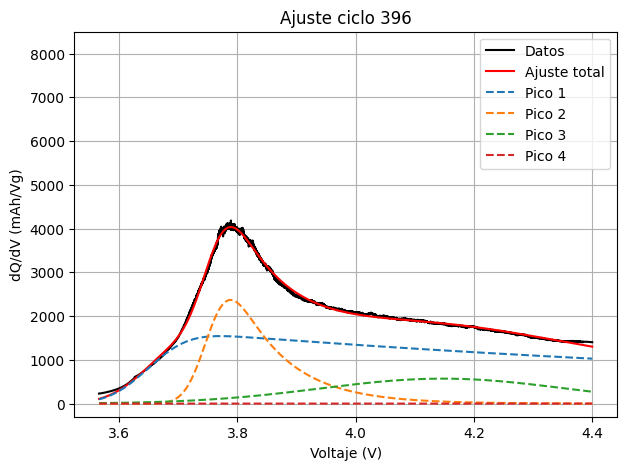

Ajustando ciclo 399...
Ajustando ciclo 402...
Ajustando ciclo 405...
Ajustando ciclo 408...
Ajustando ciclo 411...
Ajustando ciclo 414...
Ajustando ciclo 417...
Ajustando ciclo 420...
Ajustando ciclo 423...
Ajustando ciclo 426...
Ajustando ciclo 429...
Ajustando ciclo 432...
Ajustando ciclo 435...
Ajustando ciclo 438...
Ajustando ciclo 441...
Ajustando ciclo 444...
Ajustando ciclo 447...
Ajustando ciclo 450...
Ajustando ciclo 453...
Ajustando ciclo 456...
Ajustando ciclo 459...
Ajustando ciclo 462...
Ajustando ciclo 465...
Ajustando ciclo 468...
Ajustando ciclo 471...
Ajustando ciclo 474...
Ajustando ciclo 477...
Ajustando ciclo 480...
Ajustando ciclo 483...
Ajustando ciclo 486...
Ajustando ciclo 489...
Ajustando ciclo 492...
Ajustando ciclo 495...
Ajustando ciclo 498...


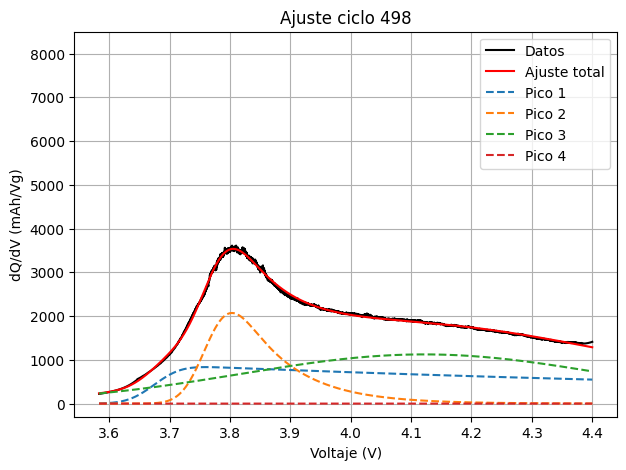

Ajustando ciclo 501...
Ajustando ciclo 504...
Ajustando ciclo 507...
Ajustando ciclo 510...
Ajustando ciclo 513...
Ajustando ciclo 516...
Ajustando ciclo 519...
Ajustando ciclo 522...
Ajustando ciclo 525...
Ajustando ciclo 528...
Ajustando ciclo 531...
Ajustando ciclo 534...
Ajustando ciclo 537...
Ajustando ciclo 540...
Ajustando ciclo 543...
Ajustando ciclo 546...
Ajustando ciclo 549...
Ajustando ciclo 552...
Ajustando ciclo 555...
Ajustando ciclo 558...
Ajustando ciclo 561...
Ajustando ciclo 564...
Ajustando ciclo 567...
Ajustando ciclo 570...
Ajustando ciclo 573...
Ajustando ciclo 576...
Ajustando ciclo 579...
Ajustando ciclo 582...
Ajustando ciclo 585...
Ajustando ciclo 588...
Ajustando ciclo 591...
Ajustando ciclo 594...
Ajustando ciclo 597...


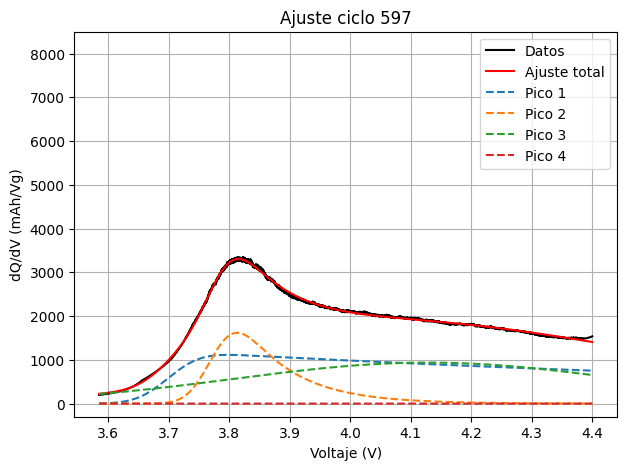

Ajustando ciclo 600...
Ajustando ciclo 603...
Ajustando ciclo 606...
Ajustando ciclo 609...
Ajustando ciclo 612...
Ajustando ciclo 615...
Ajustando ciclo 618...
Ajustando ciclo 621...
Ajustando ciclo 624...
Ajustando ciclo 627...
Ajustando ciclo 630...
Ajustando ciclo 633...
Ajustando ciclo 636...
Ajustando ciclo 639...
Ajustando ciclo 642...
Ajustando ciclo 645...
Ajustando ciclo 648...
Ajustando ciclo 651...
Ajustando ciclo 654...
Ajustando ciclo 657...
Ajustando ciclo 660...
Ajustando ciclo 663...
Ajustando ciclo 666...
Ajustando ciclo 669...
Ajustando ciclo 672...
Ajustando ciclo 675...
Ajustando ciclo 678...
Ajustando ciclo 681...
Ajustando ciclo 684...
Ajustando ciclo 687...
Ajustando ciclo 690...
Ajustando ciclo 693...
Ajustando ciclo 696...


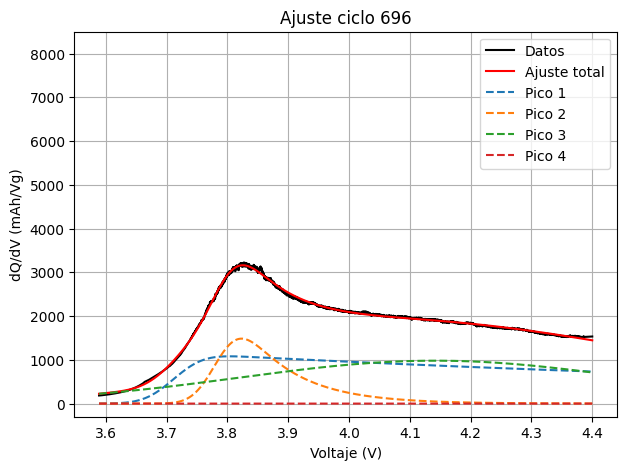

Ajustando ciclo 699...
Ajustando ciclo 702...
Ajustando ciclo 705...
Ajustando ciclo 708...
Ajustando ciclo 711...
Ajustando ciclo 714...
Ajustando ciclo 717...
Ajustando ciclo 720...
Ajustando ciclo 723...
Ajustando ciclo 726...
Ajustando ciclo 729...
Ajustando ciclo 732...
Ajustando ciclo 735...
Ajustando ciclo 738...
Ajustando ciclo 741...
Ajustando ciclo 744...
Ajustando ciclo 747...
Ajustando ciclo 750...
Ajustando ciclo 753...
Ajustando ciclo 756...
Ajustando ciclo 759...
Ajustando ciclo 762...
Ajustando ciclo 765...
Ajustando ciclo 768...
Ajustando ciclo 771...
Ajustando ciclo 774...
Ajustando ciclo 777...
Ajustando ciclo 780...
Ajustando ciclo 783...
Ajustando ciclo 786...
Ajustando ciclo 789...
Ajustando ciclo 792...
Ajustando ciclo 795...


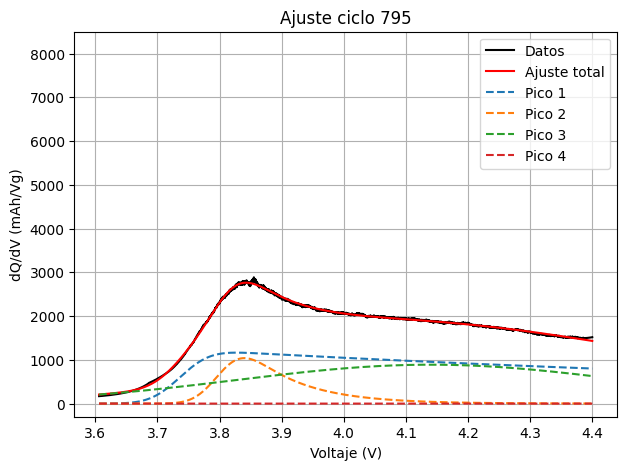

Ajustando ciclo 798...
Ajustando ciclo 801...
Ajustando ciclo 804...
Ajustando ciclo 807...
Ajustando ciclo 810...
Ajustando ciclo 813...
Ajustando ciclo 816...
Ajustando ciclo 819...
Ajustando ciclo 822...
Ajustando ciclo 825...
Ajustando ciclo 828...
Ajustando ciclo 831...
Ajustando ciclo 834...
Ajustando ciclo 837...
Ajustando ciclo 840...
Ajustando ciclo 843...
Ajustando ciclo 846...
Ajustando ciclo 849...
Ajustando ciclo 852...
Ajustando ciclo 855...
Ajustando ciclo 858...
Ajustando ciclo 861...
Ajustando ciclo 864...
Ajustando ciclo 867...
Ajustando ciclo 870...
Ajustando ciclo 873...
Ajustando ciclo 876...
Ajustando ciclo 879...
Ajustando ciclo 882...
Ajustando ciclo 885...
Ajustando ciclo 888...
Ajustando ciclo 891...
Ajustando ciclo 894...
✅ Ajustes terminados. Resultados guardados en '../output/parametros_ajustes_EMG_lf_b01_lim4-43-43-445-ressigma.csv'


,a1,mu1,sigma1,lambda1,a2,mu2,sigma2,lambda2,a3,mu3,sigma3,lambda3,a4,mu4,sigma4,lambda4
21,3818.608048,3.511459,0.039370,0.66839,747.909008,3.666575,0.024884,11.53773,80.278694,4.037777,0.092347,54.999987,1.199484e+02,4.341217,0.046223,7.153679
24,3613.448544,3.509989,0.029630,0.66839,776.446948,3.664130,0.029137,11.53773,116.954033,4.029739,0.119937,54.999987,1.353617e+02,4.334107,0.046516,7.153679
27,3645.322920,3.514156,0.033065,0.66839,777.977517,3.665338,0.023441,11.53773,104.143555,4.033408,0.102091,54.999987,1.401948e+02,4.347676,0.052701,7.153679
33,3805.573522,3.516452,0.034613,0.66839,741.169663,3.669158,0.024391,11.53773,83.928774,4.022053,0.095878,54.999987,1.020598e+02,4.354181,0.034354,7.153679
36,3680.104040,3.514152,0.029249,0.66839,766.077491,3.668888,0.025948,11.53773,107.285953,4.051431,0.102495,54.999987,1.355801e+02,4.359056,0.044711,7.153679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,2033.277250,3.766111,0.039309,0.66839,83.656535,3.828162,0.029785,11.53773,582.499515,4.123024,0.304998,54.999987,2.331193e+10,-15.034212,-0.660783,7.153679
885,2120.125076,3.769252,0.039836,0.66839,72.455447,3.830047,0.027766,11.53773,545.008411,4.112320,0.304779,54.999987,2.331193e+10,-15.034212,-0.660783,7.153679
888,2383.545818,3.774492,0.041670,0.66839,52.676034,3.831819,0.023888,11.53773,461.395986,4.091683,0.325958,54.999987,2.331193e+10,-15.034212,-0.660783,7.153679
891,2501.494024,3.777765,0.044155,0.66839,46.620568,3.832660,0.025726,11.53773,417.083226,4.082749,0.337707,54.999987,2.331193e+10,-15.034212,-0.660783,7.153679


In [9]:
# --- Ajuste de múltiples ciclos ---

# ---- Elegir ciclos del loop, nombre del .csv, parámetros iniciales y bounds ------------------
nombre = 'EMG_lf_b01_lim4-43-43-445-ressigma'
ciclos_sel = [c for c in ciclos_sel if 0 <= c <= 900]
ciclos_grafico = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]

# Elegir p_ini
p_ini_emg = [x for t in param_guess for x in t]  # aplanado

# Elegir bounds_ini manualmente
lb, ub = [], []
for (a0, mu0, sigma0, lam0) in param_guess:
    lb += [0.9*a0, 0.9*mu0, 0.9*sigma0, 0.9*lam0]
    ub += [1.1*a0, 1.1*mu0, 1.1*sigma0, 1.1*lam0]
bounds_ini_emg = (lb, ub)
# ----------------------------------------------------------------------------------------------

parametros, covs = ft.fitloop_emg_lamfijo(
    diccio,
    ciclos=ciclos_sel,
    p_ini_emg=p_ini_emg,
    bounds_ini_emg=bounds_ini_emg,
    ciclos_grafico=ciclos_grafico,
    cfg_bounds=cfg_bounds_especifico3y4
)
ft.guardar_parametros_emg(parametros, ciclos_sel, nombre)

In [23]:
# --- Trabajo con parámetros previamente ajustados ---

df_param = pd.read_csv("../output/parametros_ajustes_EMG_lf_b01_lim4-43-43-445.csv", index_col=0)
df_param.head()

,a1,mu1,sigma1,lambda1,a2,mu2,sigma2,lambda2,a3,mu3,sigma3,lambda3,a4,mu4,sigma4,lambda4
21,4555.842187,3.503277,0.019876,0.44,900.000000,3.662419,0.027000,9.9,180.000000,3.972704,0.090000,4.5,242.000000,4.419755,0.081000,6.6
24,4627.567350,3.504696,0.019629,0.44,889.068403,3.660264,0.029532,9.9,162.000000,3.965131,0.081000,4.5,246.327067,4.413772,0.072900,6.6
27,4477.894606,3.507119,0.019742,0.44,922.617445,3.661311,0.026579,9.9,164.226945,3.964108,0.072900,4.5,221.694363,4.402593,0.065610,6.6
33,4746.762517,3.509763,0.020982,0.44,866.623130,3.665465,0.025377,9.9,147.804251,3.955220,0.065610,4.5,243.863799,4.424181,0.059049,6.6
36,4802.035001,3.509368,0.020611,0.44,866.660548,3.665448,0.025831,9.9,133.023826,3.978920,0.059049,4.5,245.531574,4.419650,0.053144,6.6


In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

In [44]:

def plot_emg_fit_poster(df_ch, popt, nombre_ciclo=None, ylim=(-0.6, 8.5),
                        save_path=None, legend=True, legend_picos=True):
    """
    Gráfico para póster científico (~15x10 cm).
    Estilo: tipografía grande, líneas más gruesas, picos sólidos y suma punteada.
    Sin recuadro (solo ejes x e y visibles).

    legend_picos : bool
        Si True, muestra cada pico en la leyenda.
        Si False, no muestra los picos.
        El número de ciclo solo se indica en "Datos".
    """
    # --- Estilo general ---
    mpl.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "legend.fontsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "axes.linewidth": 1.4,
    })

    V = df_ch['V_ch_savgol'].values
    dqdv = df_ch['dqdv_ch_calc'].values

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)  # ~15x10 cm

    # --- Datos experimentales ---
    label_datos = f"Datos (Ciclo {nombre_ciclo})" if nombre_ciclo else "Datos"
    ax.plot(V, dqdv/1000, color='darkgray', linewidth=1, label=label_datos)

    # --- Picos individuales ---
    n_peaks = len(popt) // 4
    colors = ["#1283C5", "#D99C33", "#3AA341", "#E444B7", "#D55E00"]
    for i in range(n_peaks):
        a, mu, sigma, lam = popt[4*i:4*i+4]
        label_pico = f"Pico {i+1}" if legend_picos else None
        ax.plot(
            V, ft.emg(V, a, mu, sigma, lam)/1000,
            color=colors[i % len(colors)],
            linewidth=1.3, alpha=0.9,
            label=label_pico
        )

    # --- Ajuste total ---
    label_total = "Suma total" if legend_picos else None
    y_fit = ft.multi_emg(V, *popt)
    ax.plot(V, y_fit/1000, linestyle='--', color='r', linewidth=1, label=label_total)

    # --- Etiquetas y formato ---
    ax.set_xlabel("Voltaje (V)", labelpad=8)
    ax.set_ylabel("dQ/dV (Ah/Vg)", labelpad=8)
    #if nombre_ciclo:
        #ax.set_title(f"Ciclo {nombre_ciclo}", pad=10)
    ax.set_ylim(ylim)

    ax.grid(True, alpha=0.25, linewidth=1)
    if legend:
        ax.legend(frameon=False, loc='best', ncol=1)

    # --- Solo ejes X e Y visibles ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
    else:
        plt.show()


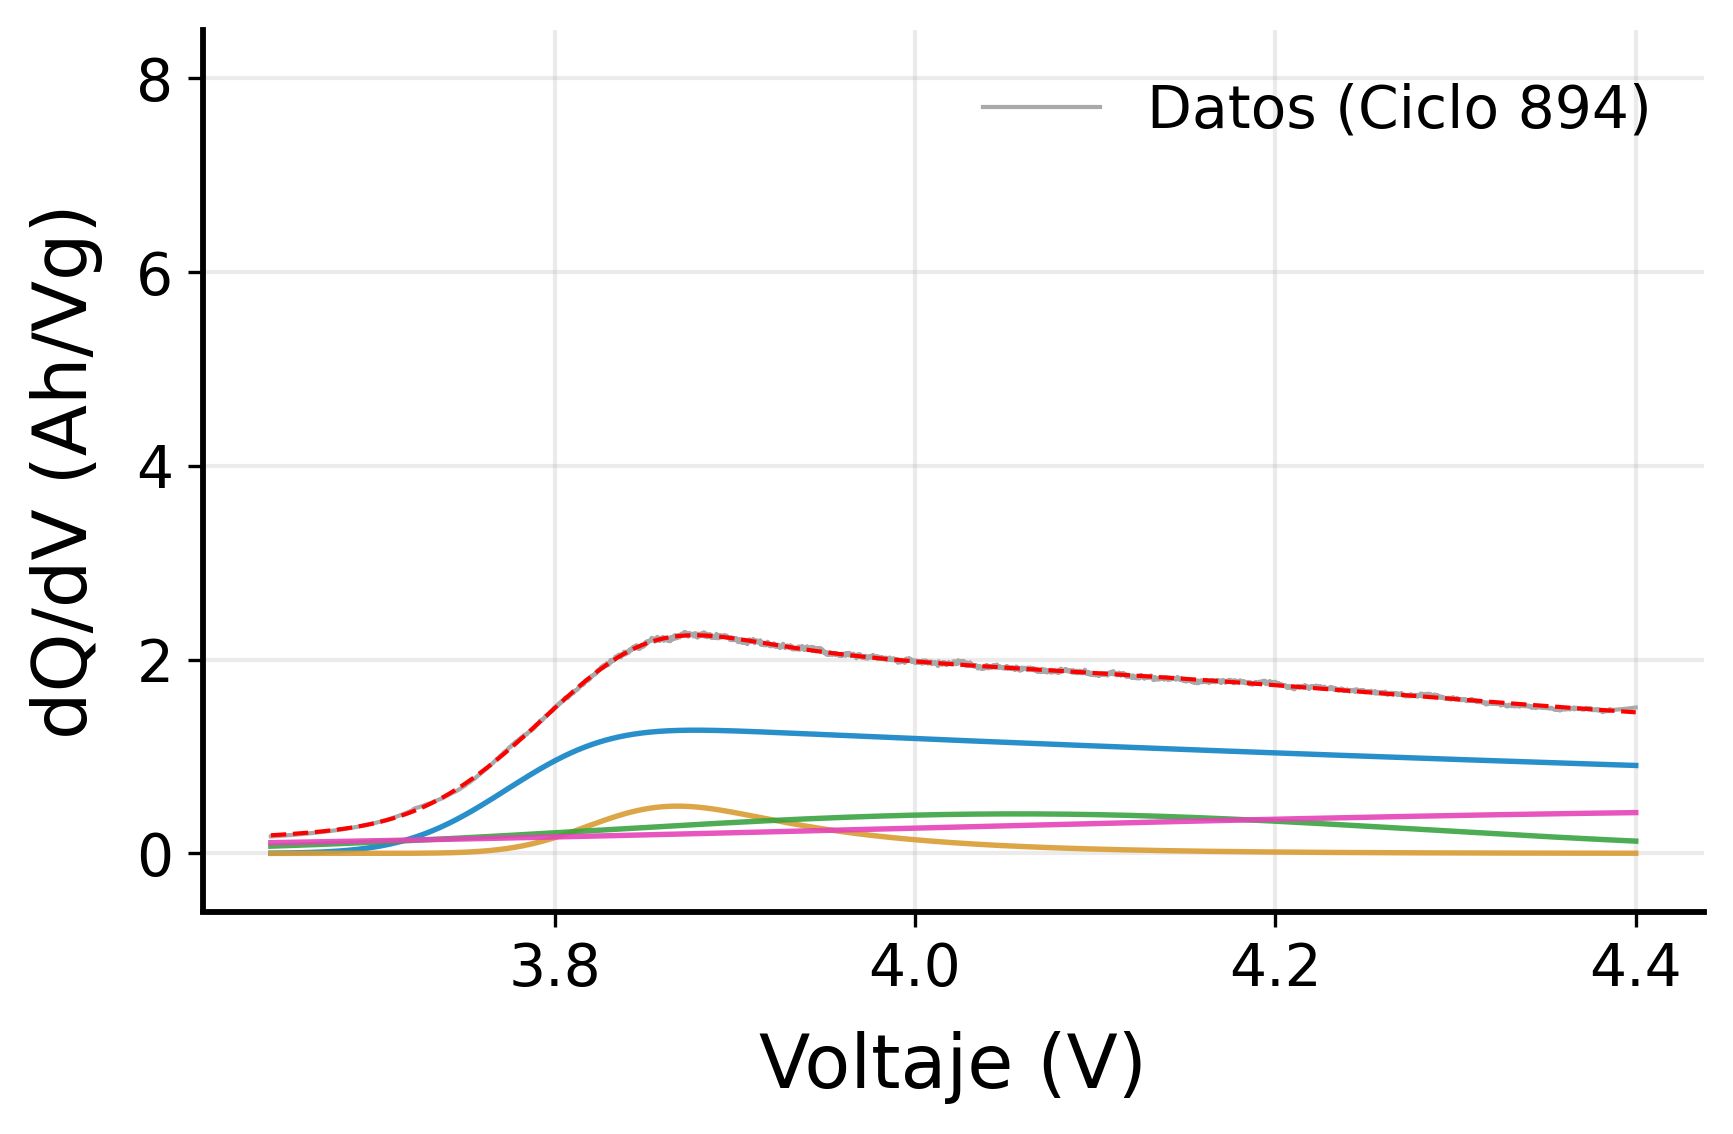

In [48]:
# --- Plot de un ciclo en particular PARA POSTER ---

#lim4-43-43-445
#lim35-445

# ------ Elegir cuál y de qué loop ---------------
ciclo = 894
df_param = pd.read_csv("../output/parametros_ajustes_EMG_lf_b01_lim4-43-43-445-ini01.csv", index_col=0)
nombre = 'EMG_lf_b01_lim4-43-43-445-ini01' # etiqueta gráfico
# ------------------------------------------------

# Ajuste del ciclo i de carga
df_ch_i = diccio[ciclo]['Ch']
popt_i = df_param.loc[ciclo].values

plot_emg_fit_poster(df_ch_i, popt_i, save_path=f'../output/ajuste_POSTER_C{ciclo}_{nombre}.png', nombre_ciclo=ciclo, legend=True, legend_picos=False)

In [66]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_param_evolution(df, param, n_peaks, nombre, exclude_peaks=None, max_xticks=10):
    """
    Grafica la evolución de un parámetro (a, mu, sigma, lambda) para todos los picos.
    Ajusta automáticamente las unidades del eje y según el parámetro.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los parámetros (columnas como 'a1', 'mu1', etc.)
    param : str
        Nombre base del parámetro ('a', 'mu', 'sigma', 'lambda')
    n_peaks : int
        Número de picos
    nombre : str
        Etiqueta para el archivo de salida
    exclude_peaks : list[int], optional
        Índices de picos a excluir (base 0)
    max_xticks : int, optional
        Número máximo de ticks en el eje x (default 10)
    """
    exclude_peaks = exclude_peaks or []
    colors = ["#1283C5", "#D99C33", "#3AA341", "#E444B7", "#D55E00"]

    # Mapeo de unidades por parámetro
    unidades = {
        'a': 'Ah/Vg',
        'mu': 'V',
        'sigma': 'V',
        'lambda': '1/V'
    }
    unidad = unidades.get(param, '')

    plt.figure(figsize=(5.5,4.5))
    for i in range(n_peaks):
        if i not in exclude_peaks:
            y = df[f"{param}{i+1}"].values
            # Escalar si es parámetro 'a'
            if param == 'a':
                y = y / 1000
            plt.plot(
                df.index, y,
                'o-', color=colors[i % len(colors)],
                label=f"Pico {i+1}", markersize=0
            )

    plt.xlabel("Ciclo")
    if unidad:
        plt.ylabel(f"{param} ({unidad})")
    else:
        plt.ylabel(param)

    #plt.title(f"Evolución parámetro {param}")
    if param not in ['mu']:
        plt.legend()
    plt.grid(True)

    # Ticks automáticos eje x
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True))

    plt.tight_layout()
    plt.savefig(f"../output/evolucion_{param}_{nombre}.png", dpi=300)
    plt.show()

Index([ 21,  24,  27,  33,  36,  39,  42,  45,  48,  51,
       ...
       867, 870, 873, 876, 879, 882, 885, 888, 891, 894],
      dtype='int64', length=288)


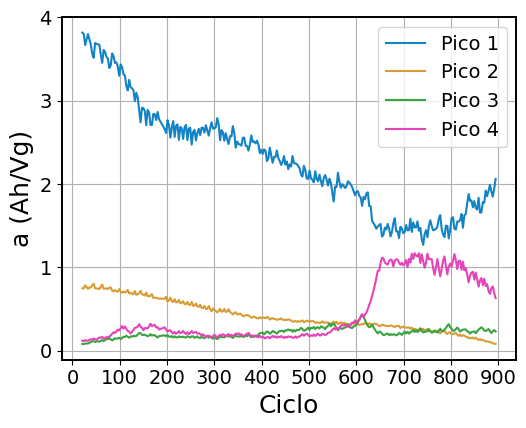

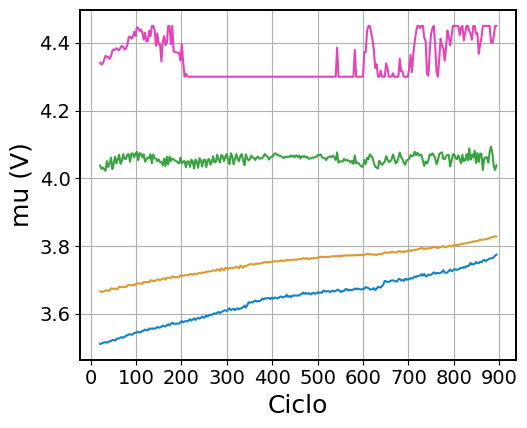

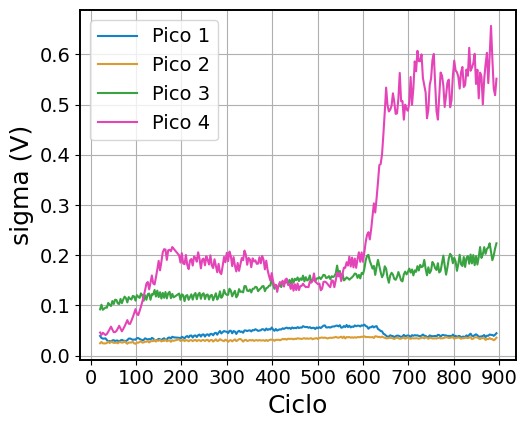

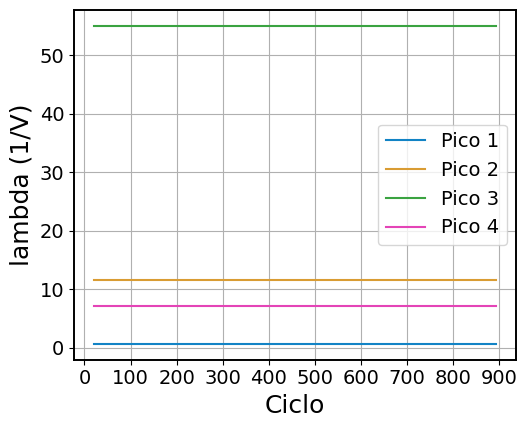

In [67]:
# Leer datos

#lim35-445
#lim4-43-43-445

# ------ Elegir de qué loop ---------------
df_params = pd.read_csv("../output/parametros_ajustes_EMG_lf_b01_lim4-43-43-445-ini01.csv", index_col=0)
nombre = 'EMG_lf_b01_lim4-43-43-445-ini01' # etiqueta gráfico
# ------------------------------------------------

print(df_params.index)
n_peaks = 4

# Graficar todos los parámetros
for p in ['a', 'mu', 'sigma', 'lambda']:
    plot_param_evolution(df_params, p, n_peaks, nombre, exclude_peaks=[])